# Autoencoder + XGBoost

Este notebook implementa um pipeline de classificação de imagens CPRE (ERCP) baseado num Autoencoder convolucional. As representações do espaço latente (2048 dimensões) são usadas como entrada para um classificador XGBoost.

Modelo treinado no Kaggle com o GPU T4 x2


## Imports necessários

In [ ]:
!pip install -q xgboost scikit-learn

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

from xgboost import XGBClassifier

DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE    = 8 
LATENT_DIM    = 2048 # dimensão do espaço latente
EPOCHS        = 50
LEARNING_RATE = 3e-4
IMAGE_SIZE    = 128

print(f'Device: {DEVICE}')


Device: cuda


## Caminhos

In [ ]:
base_dir = '/kaggle/input/datasets/jasminazul/dataset_monica/dataset'  

print('base_dir existe:', os.path.isdir(base_dir))
# Verificar estrutura
for phase in ['train', 'val', 'test']:
    p = os.path.join(base_dir, phase)
    print(f'  {phase}/  existe: {os.path.isdir(p)}')


base_dir existe: True
  train/  existe: True
  val/  existe: True
  test/  existe: True


## Carregar Dataset

In [ ]:
valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff') # extensões de imagem aceites
phases     = ['train', 'val', 'test']

# Descobrir classes a partir da pasta train
class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])
num_class = len(class_names)
print('Classes:', class_names)

data = {phase: {'images': [], 'labels': []} for phase in phases}

for phase in phases:
    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        if not os.path.isdir(class_dir):
            continue
        files = [
            os.path.join(class_dir, f)
            for f in os.listdir(class_dir)
            if f.lower().endswith(valid_exts)
        ]
        data[phase]['images'].extend(files)
        data[phase]['labels'].extend([idx] * len(files))
    print(f'{phase.capitalize():6s}: {len(data[phase]["images"])} imagens')


Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Train : 1067 imagens
Val   : 234 imagens
Test  : 267 imagens


## Transforms e DataLoaders
Pré-processamento: converte para grayscale, redimensiona e normaliza.
Cria os DataLoaders para train, val e test.

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), # converte para grayscale (1 canal)
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

class MedicalDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths) # número total de amostras

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# cria os três datasets e dataloaders
train_ds = MedicalDataset(data['train']['images'], data['train']['labels'], transform)
val_ds   = MedicalDataset(data['val']['images'],   data['val']['labels'],   transform)
test_ds  = MedicalDataset(data['test']['images'],  data['test']['labels'],  transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')


Train: 1067 | Val: 234 | Test: 267


## Autoencoder Convolucional


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, latent_dim)
        )

        self.decoder_fc = nn.Linear(latent_dim, 64 * 16 * 16)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 1,  kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z   = self.encoder(x)
        out = self.decoder_fc(z)
        out = out.view(-1, 64, 16, 16)
        out = self.decoder(out) # reconstrói a imagem
        return out

# instancia o modelo, loss, optimizador e scheduler
model     = Autoencoder(latent_dim=LATENT_DIM).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f'Parâmetros: {sum(p.numel() for p in model.parameters()):,}')


Parâmetros: 67,192,177


## Treino do Autoencoder
Treina durante 50 épocas

In [8]:
best_loss = float('inf')
ae_save   = './autoencoder_ercp_train_032_sem_sinteticos.pth'

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images_batch, _ in train_loader:
        images_batch = images_batch.to(DEVICE)
        outputs      = model(images_batch)
        loss         = criterion(outputs, images_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    scheduler.step()

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), ae_save)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}  Loss: {avg_loss:.6f}  Best: {best_loss:.6f}')

print(f'\nMelhor loss: {best_loss:.6f}')


Epoch   1/50  Loss: 0.026253  Best: 0.026253
Epoch  10/50  Loss: 0.002156  Best: 0.002156
Epoch  20/50  Loss: 0.001119  Best: 0.001119
Epoch  30/50  Loss: 0.000713  Best: 0.000713
Epoch  40/50  Loss: 0.000511  Best: 0.000511
Epoch  50/50  Loss: 0.000461  Best: 0.000453

Melhor loss: 0.000453


## Verificação Visual das Reconstruções

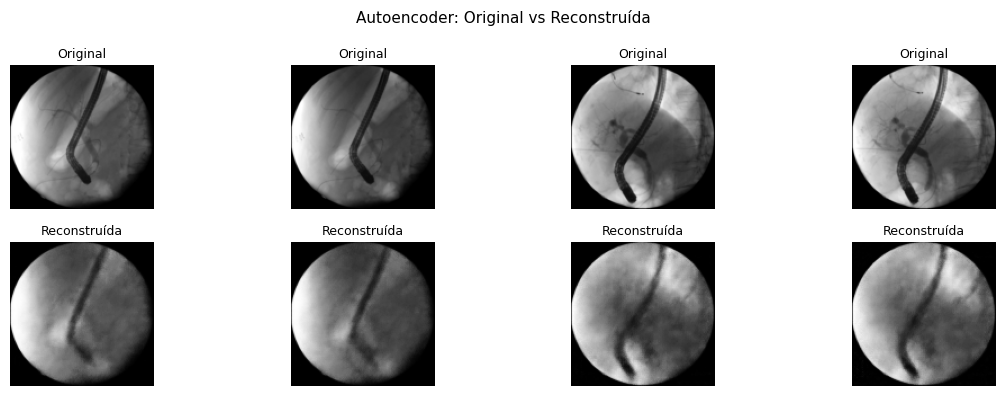

In [9]:
model.load_state_dict(torch.load(ae_save, map_location=DEVICE))
model.eval()

with torch.no_grad():
    imgs, _ = next(iter(val_loader))
    imgs    = imgs.to(DEVICE)
    recon   = model(imgs)

plt.figure(figsize=(12, 4))
for i in range(min(4, len(imgs))):
    plt.subplot(2, 4, i+1)
    plt.imshow(imgs[i][0].cpu(), cmap='gray')
    plt.title('Original', fontsize=9)
    plt.axis('off')
    plt.subplot(2, 4, i+5)
    plt.imshow(recon[i][0].cpu(), cmap='gray')
    plt.title('Reconstruída', fontsize=9)
    plt.axis('off')
plt.suptitle('Autoencoder: Original vs Reconstruída', fontsize=11)
plt.tight_layout()
plt.show()


## Extração de Features (Espaço Latente)

In [ ]:
def extract_features(dataloader, model, device):
    model.eval()
    features, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(device)
            z    = model.encoder(imgs)
            features.append(z.cpu().numpy())
            all_labels.append(lbls.numpy())
    return np.concatenate(features), np.concatenate(all_labels)

# extração de features para os 3 conjuntos
print('A extrair features...')
X_train_feat, y_train_feat = extract_features(train_loader, model, DEVICE)
X_val_feat,   y_val_feat   = extract_features(val_loader,   model, DEVICE)
X_test_feat,  y_test_feat  = extract_features(test_loader,  model, DEVICE)

print(f'X_train: {X_train_feat.shape}')
print(f'X_val  : {X_val_feat.shape}')
print(f'X_test : {X_test_feat.shape}')


A extrair features...
X_train: (1067, 2048)
X_val  : (234, 2048)
X_test : (267, 2048)


## XGBoost com Class Weights

In [ ]:
# calcular Class weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_feat),
    y=y_train_feat
)

sample_weights = np.array([weights[l] for l in y_train_feat])

print('Class weights:')
for name, w in zip(class_names, weights):
    print(f'  {name}: {w:.4f}')

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=num_class,
    eval_metric='mlogloss',
    random_state=42
)

print('\nA treinar XGBoost (TRAIN)...')

xgb_model.fit(
    X_train_feat,
    y_train_feat,
    sample_weight=sample_weights,
    eval_set=[(X_val_feat, y_val_feat)],
    verbose=50
)

Class weights:
  Biliary_Leaks: 2.4250
  Lithiasis: 0.5282
  Normal: 1.3541
  Stricture: 1.0461

A treinar XGBoost (TRAIN)...
[0]	validation_0-mlogloss:1.38026
[50]	validation_0-mlogloss:1.33523
[100]	validation_0-mlogloss:1.42714
[149]	validation_0-mlogloss:1.53215


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None, num_class=4, ...)

## Avaliação Final no test set

Accuracy : 0.4569
F1 Macro : 0.3250

               precision    recall  f1-score   support

Biliary_Leaks     1.0000    0.1176    0.2105        17
    Lithiasis     0.4732    0.7886    0.5915       123
       Normal     0.2895    0.2558    0.2716        43
    Stricture     0.5455    0.1429    0.2264        84

     accuracy                         0.4569       267
    macro avg     0.5770    0.3262    0.3250       267
 weighted avg     0.4999    0.4569    0.4008       267



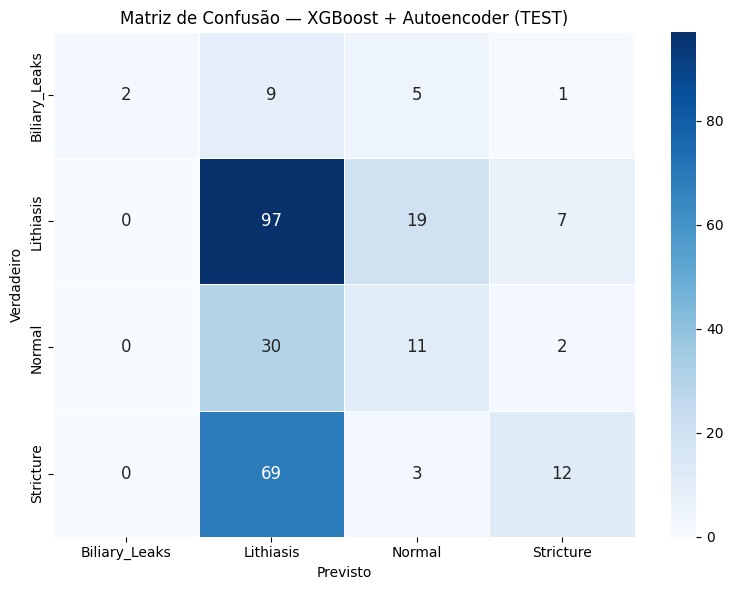

In [ ]:
preds = xgb_model.predict(X_test_feat) # predições no conjunto de teste

acc = accuracy_score(y_test_feat, preds)
f1  = f1_score(y_test_feat, preds, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1 Macro : {f1:.4f}')
print()

print(classification_report(
    y_test_feat,
    preds,
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_test_feat, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    linewidths=0.5,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={'size': 12},
    cmap='Blues'
)

plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.title('Matriz de Confusão — XGBoost + Autoencoder (TEST)')
plt.tight_layout()
plt.savefig('./confusion_matrix_xgb_test.png', dpi=300)
plt.show()